In [36]:
import pandas as pd
from src.utils import load_env
from matplotlib import pyplot as plt
import seaborn as sns

from case_study.utils import blue_hex, yellow_hex, lt_blue_hex, red_hex, white_hex

env_vars = load_env()

In [37]:
input_path = f"{env_vars['RESULTS_DIR']}/cluster_embeddings/pckmeans/podcasts/mets_only_qwen_fe_clusters_225_w0.1.csv"
df = pd.read_csv(input_path)
df["doc_year"] = df["doc_year"].astype(int)

In [38]:
# Maps raw `channel` values in the sheet to properly formatted display names.
channel_display_names = {
    'mark levin podcast':                             'Mark Levin Podcast',
    'pod save america':                               'Pod Save America',
    'the dan bongino show':                           'The Dan Bongino Show',
    'the megyn kelly show':                           'The Megyn Kelly Show',
    'the meidastouch podcast':                        'MeidasTouch Podcast',
    'the michael moore podcast':                      'The Michael Moore Podcast',
    'the sean hannity show':                          'The Sean Hannity Show',
    'the tucker carlson show':                        'The Tucker Carlson Show',
    'the young turks':                                'The Young Turks',
    'why is this happening the chris hayes podcast':  'Why Is This Happening? (Chris Hayes)',
}

# usage: add a display-name column, or just relabel on the fly in a plot
df['channel_display'] = df['channel'].map(channel_display_names)

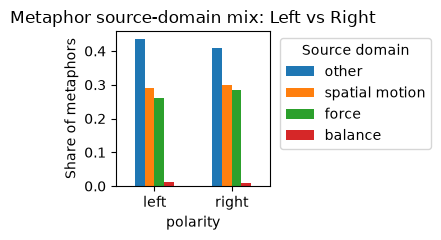

In [39]:
def plot_schema_by_polarity(df):
    ct = pd.crosstab(df['polarity'], df['source_image_schema_group'], normalize='index')
    ct = ct[ct.mean().sort_values(ascending=False).index]
    fig, ax = plt.subplots(figsize=(4,2.5))
    ct.plot(kind='bar', ax=ax)
    ax.set_ylabel('Share of metaphors')
    ax.set_title('Metaphor source-domain mix: Left vs Right')
    ax.legend(title='Source domain', bbox_to_anchor=(1.02,1), loc='upper left')
    plt.xticks(rotation=0)
    plt.tight_layout()
    return fig

fig0 = plot_schema_by_polarity(df)

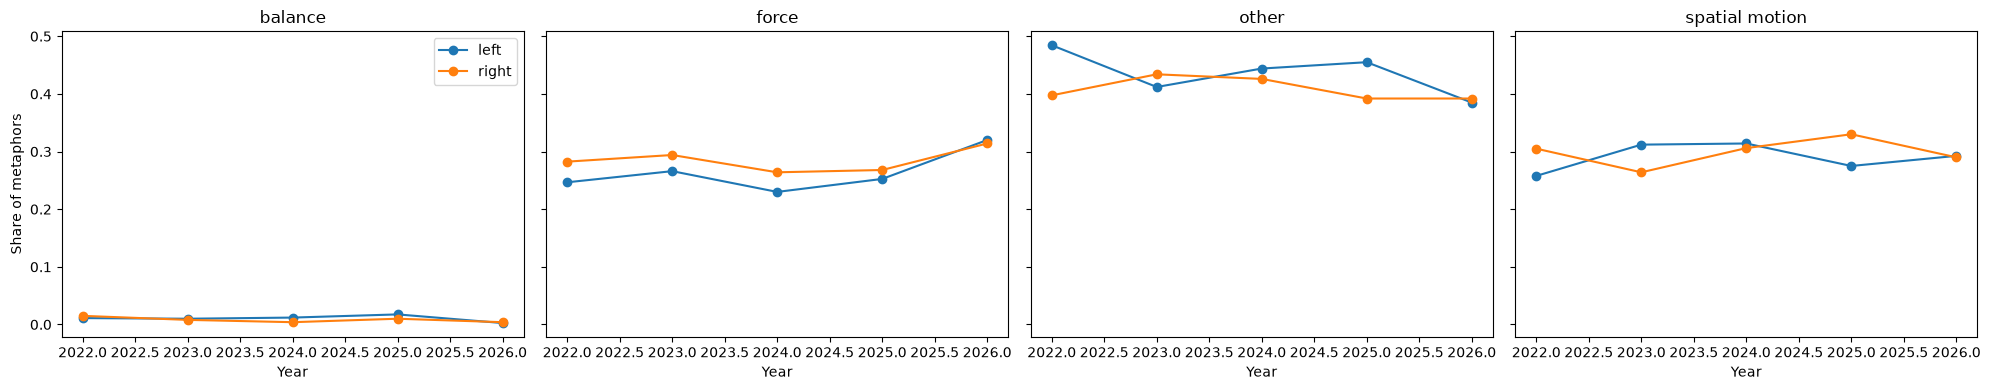

In [40]:
def plot_schema_over_time(df):
    grp = df.groupby(['doc_year','polarity','source_image_schema_group']).size().reset_index(name='n')
    totals = df.groupby(['doc_year','polarity']).size().reset_index(name='total')
    grp = grp.merge(totals, on=['doc_year','polarity'])
    grp['share'] = grp['n']/grp['total']
    schemas = grp['source_image_schema_group'].unique()
    fig, axes = plt.subplots(1, len(schemas), figsize=(5*len(schemas),4), sharey=True)
    for ax, schema in zip(axes, schemas):
        sub = grp[grp['source_image_schema_group']==schema]
        for pol, sub2 in sub.groupby('polarity'):
            sub2 = sub2.sort_values('doc_year')
            ax.plot(sub2['doc_year'], sub2['share'], marker='o', label=pol)
        ax.set_title(schema)
        ax.set_xlabel('Year')
    axes[0].set_ylabel('Share of metaphors')
    axes[0].legend()
    plt.tight_layout()
    return fig

fig1 = plot_schema_over_time(df)


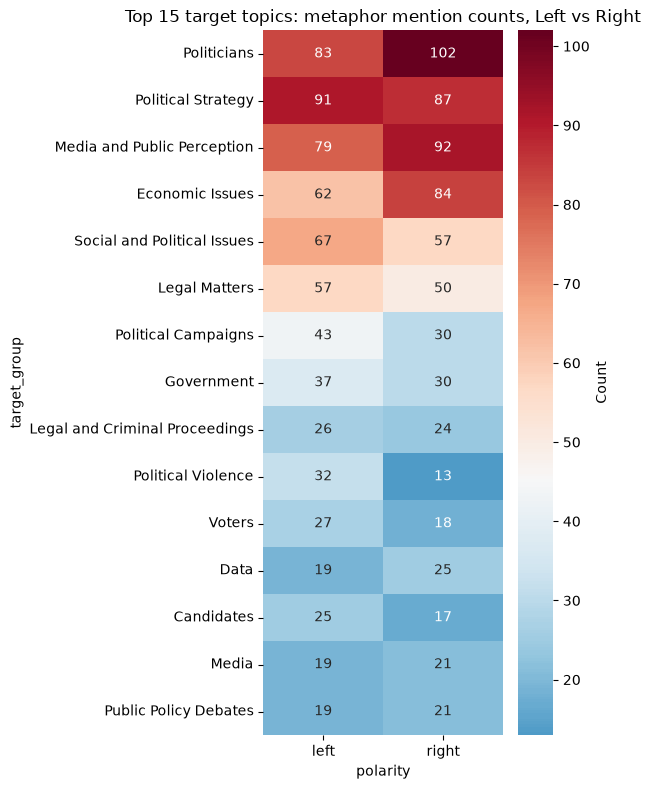

In [41]:
def plot_topic_heatmap(df, top_n=15):
    sub = df[df['target_group'] != 'Other']
    top_groups = sub['target_group'].value_counts().head(top_n).index
    sub = sub[sub['target_group'].isin(top_groups)]
    ct = pd.crosstab(sub['target_group'], sub['polarity'])
    ct = ct.loc[top_groups]
    fig, ax = plt.subplots(figsize=(6, 0.4*top_n+2))
    sns.heatmap(ct, annot=True, fmt='d', cmap='RdBu_r', center=ct.values.mean(),
                ax=ax, cbar_kws={'label':'Count'})
    ax.set_title(f'Top {top_n} target topics: metaphor mention counts, Left vs Right')
    plt.tight_layout()
    return fig

fig2 = plot_topic_heatmap(df)

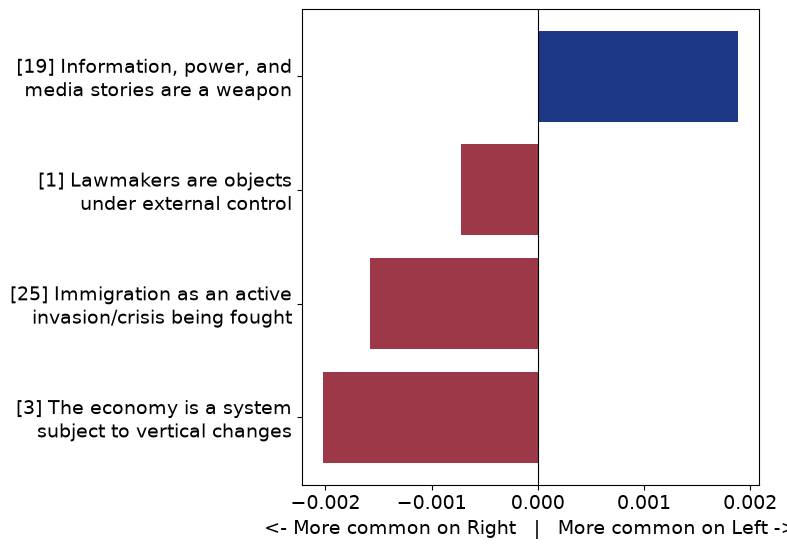

In [42]:
import textwrap

# Manual annotations go here -- keyed by clust_imp_rank. Add more as you annotate them.
cluster_labels = {
    1: "Lawmakers are objects under external control",
    3: "The economy is a system subject to vertical changes",
    19: "Information, power, and media stories are a weapon",
    25: "Immigration as an active invasion/crisis being fought"
}

def plot_annotated_clusters(df, cluster_labels, wrap_width=30, fontsize=14):
    counts = df.groupby(['clust_imp_rank','polarity']).size().unstack(fill_value=0)
    totals = df['polarity'].value_counts()
    share_left = counts.get('left',0)/totals.get('left',1)
    share_right = counts.get('right',0)/totals.get('right',1)
    diff = share_left - share_right

    annotated = list(cluster_labels.keys())
    plot_df = pd.DataFrame({'diff': diff.loc[annotated]})
    plot_df['label'] = [
        "\n".join(textwrap.wrap(f"[{c}] {cluster_labels[c]}", width=wrap_width))
        for c in plot_df.index
    ]
    plot_df = plot_df.sort_values('diff')

    fig, ax = plt.subplots(figsize=(8, 0.9*len(plot_df)+2))
    colors = [red_hex if v<0 else blue_hex for v in plot_df['diff']]
    ax.barh(plot_df['label'], plot_df['diff'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('<- More common on Right   |   More common on Left ->', fontsize=fontsize)
    # ax.set_title('Annotated conceptual metaphors: Left vs Right framing', fontsize=fontsize+2)
    ax.tick_params(axis='both', labelsize=fontsize)
    plt.tight_layout()
    return fig

fig4 = plot_annotated_clusters(df, cluster_labels)
fig4.savefig('figures/ann_cm_polarity.png', dpi=300)  # dpi bump helps if you're embedding in LaTeX/Word


In [43]:
def plot_cluster_trend(df, cluster_ids):
    sub = df[df['cluster'].isin(cluster_ids)].copy()
    sub['label'] = sub['cluster'].apply(lambda c: get_cluster_label(df, c))
    grp = sub.groupby(['doc_year','polarity','label']).size().reset_index(name='n')
    labels = sub['label'].unique()
    fig, axes = plt.subplots(1, len(labels), figsize=(10*len(labels),4), sharey=False)
    if len(labels)==1:
        axes = [axes]
    for ax, label in zip(axes, labels):
        s = grp[grp['label']==label]
        for pol, s2 in s.groupby('polarity'):
            s2 = s2.sort_values('doc_year')
            ax.plot(s2['doc_year'], s2['n'], marker='o', label=pol)
        ax.set_title(label, fontsize=9)
        ax.set_xlabel('Year')
    axes[0].set_ylabel('Count')
    axes[0].legend()
    plt.tight_layout()
    return fig

# usage: pick clusters from the diverging chart, e.g.
# plot_cluster_trend(df, cluster_ids=[80, 135, 57])
# fig4 = plot_cluster_trend(df, cluster_ids=[7])

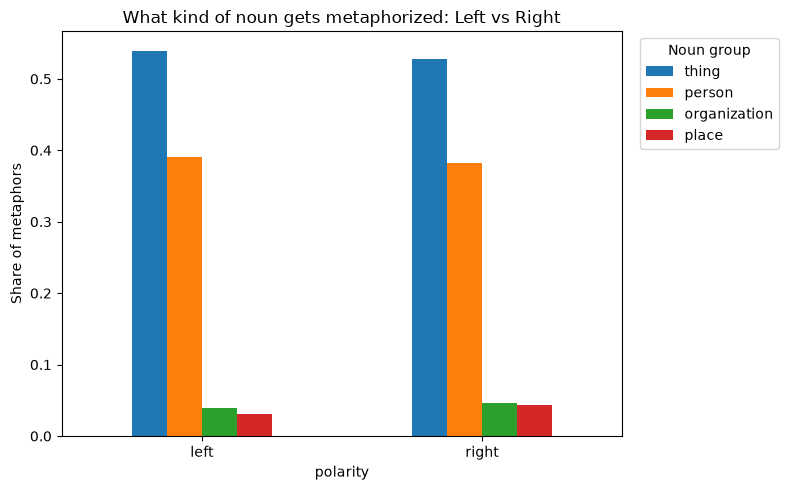

In [44]:
def plot_ppto_by_polarity(df):
    ct = pd.crosstab(df['polarity'], df['target_ppto'], normalize='index')
    ct = ct[ct.mean().sort_values(ascending=False).index]
    fig, ax = plt.subplots(figsize=(8,5))
    ct.plot(kind='bar', ax=ax)
    ax.set_ylabel('Share of metaphors')
    ax.set_title('What kind of noun gets metaphorized: Left vs Right')
    ax.legend(title='Noun group', bbox_to_anchor=(1.02,1), loc='upper left')
    plt.xticks(rotation=0)
    plt.tight_layout()
    return fig
fig5 = plot_ppto_by_polarity(df)

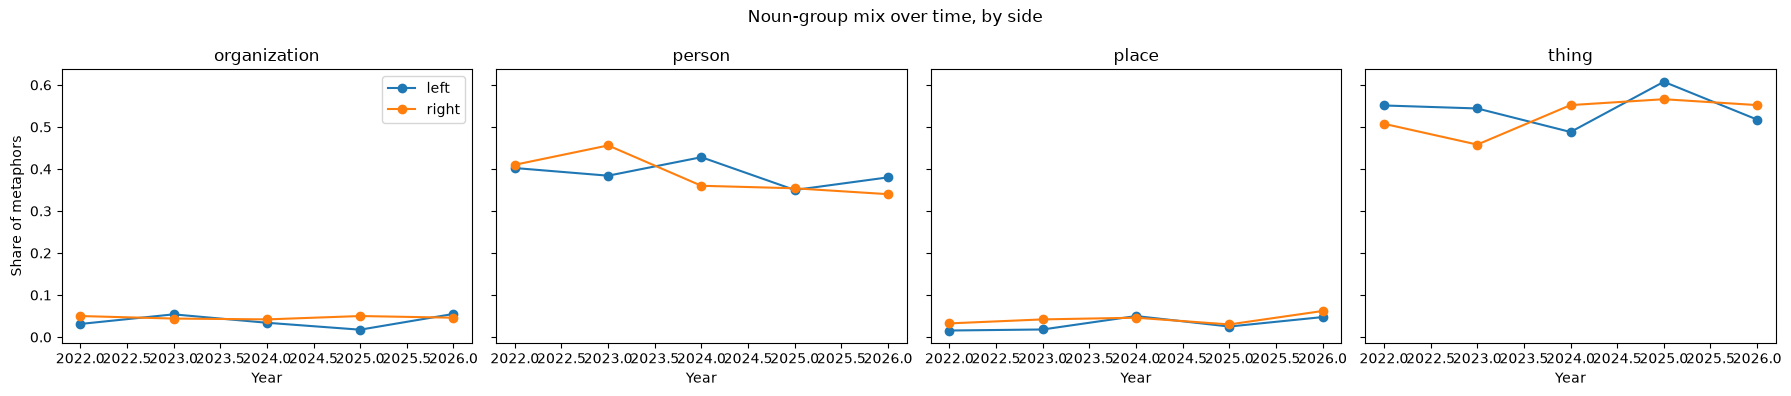

In [45]:
def plot_ppto_over_time(df):
    grp = df.groupby(['doc_year','polarity','target_ppto']).size().reset_index(name='n')
    totals = df.groupby(['doc_year','polarity']).size().reset_index(name='total')
    grp = grp.merge(totals, on=['doc_year','polarity'])
    grp['share'] = grp['n']/grp['total']
    groups = grp['target_ppto'].unique()
    fig, axes = plt.subplots(1, len(groups), figsize=(4.5*len(groups),4), sharey=True)
    for ax, g in zip(axes, groups):
        sub = grp[grp['target_ppto']==g]
        for pol, sub2 in sub.groupby('polarity'):
            sub2 = sub2.sort_values('doc_year')
            ax.plot(sub2['doc_year'], sub2['share'], marker='o', label=pol)
        ax.set_title(g)
        ax.set_xlabel('Year')
    axes[0].set_ylabel('Share of metaphors')
    axes[0].legend()
    plt.suptitle('Noun-group mix over time, by side')
    plt.tight_layout()
    return fig
fig6 = plot_ppto_over_time(df)

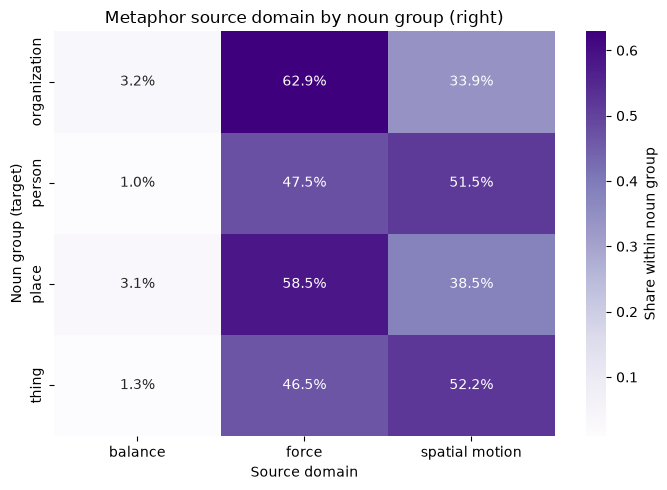

In [46]:
def plot_schema_by_ppto(df, polarity=None):
    sub = df if polarity is None else df[df['polarity']==polarity]
    sub = sub[sub['source_image_schema_group'] != 'other']
    ct = pd.crosstab(sub['target_ppto'], sub['source_image_schema_group'], normalize='index')
    fig, ax = plt.subplots(figsize=(7,5))
    sns.heatmap(ct, annot=True, fmt='.1%', cmap='Purples', ax=ax, cbar_kws={'label':'Share within noun group'})
    title = 'Metaphor source domain by noun group'
    if polarity:
        title += f' ({polarity})'
    ax.set_title(title)
    ax.set_xlabel('Source domain')
    ax.set_ylabel('Noun group (target)')
    plt.tight_layout()
    return fig


# fig3a = plot_schema_by_ppto(df, polarity='left')
fig7b = plot_schema_by_ppto(df, polarity='right')

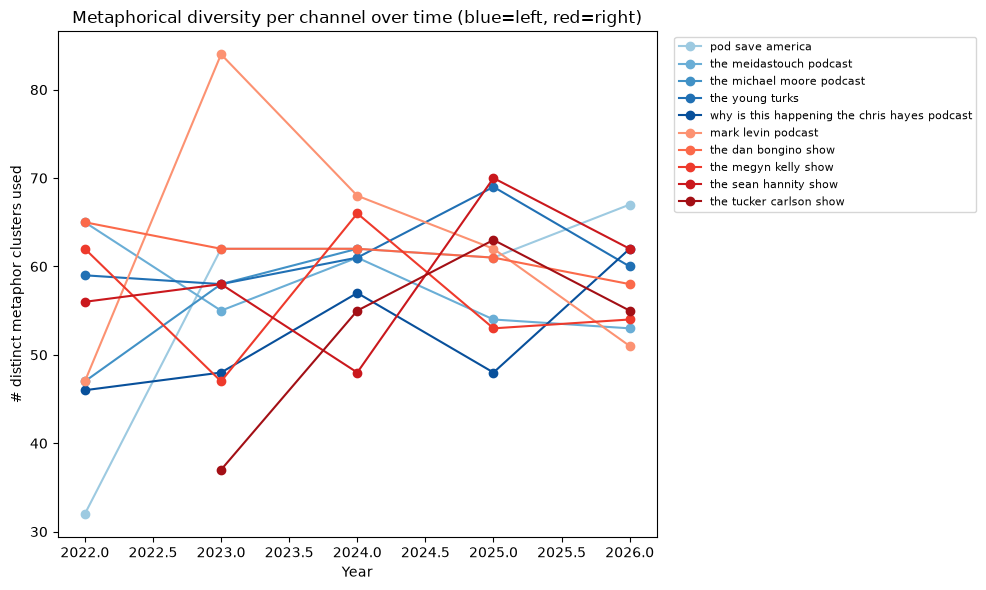

In [47]:
channel_order = (df[['channel','polarity']].drop_duplicates()
                  .sort_values(['polarity','channel'])['channel'].tolist())

def plot_channel_diversity_over_time(df):
    grp = df.groupby(['doc_year','channel','polarity'])['cluster'].nunique().reset_index(name='n_clusters')
    left_ch = sorted(grp[grp.polarity=='left']['channel'].unique())
    right_ch = sorted(grp[grp.polarity=='right']['channel'].unique())
    left_colors = sns.color_palette('Blues', n_colors=len(left_ch)+2)[2:]
    right_colors = sns.color_palette('Reds', n_colors=len(right_ch)+2)[2:]
    palette = dict(zip(left_ch, left_colors)) | dict(zip(right_ch, right_colors))
    fig, ax = plt.subplots(figsize=(10,6))
    for ch in channel_order:
        sub = grp[grp.channel==ch].sort_values('doc_year')
        ax.plot(sub['doc_year'], sub['n_clusters'], marker='o', label=ch, color=palette[ch])
    ax.set_xlabel('Year')
    ax.set_ylabel('# distinct metaphor clusters used')
    ax.set_title('Metaphorical diversity per channel over time (blue=left, red=right)')
    ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
    plt.tight_layout()
    return fig

fig9 = plot_channel_diversity_over_time(df)

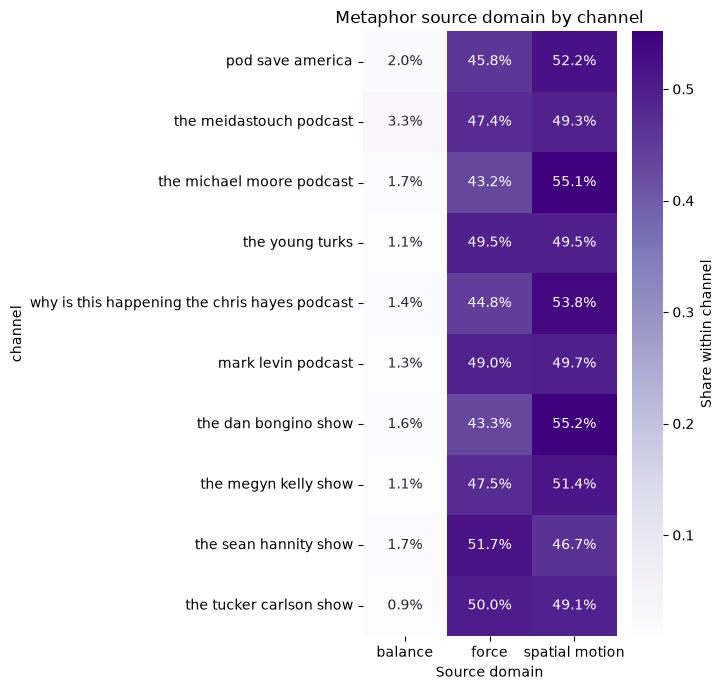

In [48]:
def plot_channel_schema_heatmap(df):
    sub = df[df['source_image_schema_group'] != 'other']
    ct = pd.crosstab(sub['channel'], sub['source_image_schema_group'], normalize='index')
    ct = ct.loc[channel_order]
    fig, ax = plt.subplots(figsize=(7, 0.5*len(channel_order)+2))
    sns.heatmap(ct, annot=True, fmt='.1%', cmap='Purples', ax=ax, cbar_kws={'label':'Share within channel'})
    ax.set_title('Metaphor source domain by channel')
    ax.set_xlabel('Source domain')
    plt.tight_layout()
    return fig
fig10 = plot_channel_schema_heatmap(df)

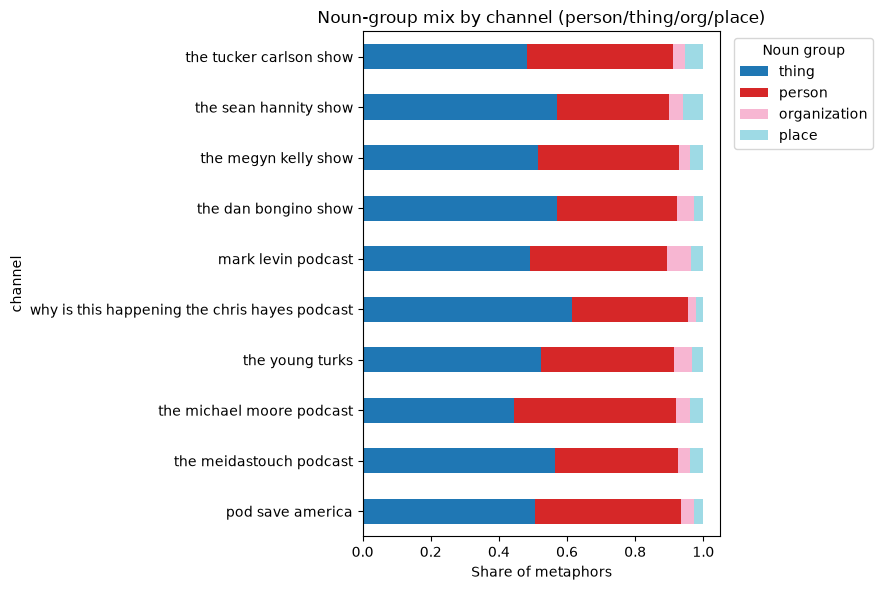

In [49]:
def plot_channel_ppto_bar(df):
    ct = pd.crosstab(df['channel'], df['target_ppto'], normalize='index')
    ct = ct.loc[channel_order]
    ct = ct[ct.mean().sort_values(ascending=False).index]
    fig, ax = plt.subplots(figsize=(9,6))
    ct.plot(kind='barh', stacked=True, ax=ax, colormap='tab20')
    ax.set_xlabel('Share of metaphors')
    ax.set_title('Noun-group mix by channel (person/thing/org/place)')
    ax.legend(title='Noun group', bbox_to_anchor=(1.02,1), loc='upper left')
    plt.tight_layout()
    return fig
fig11 = plot_channel_ppto_bar(df)

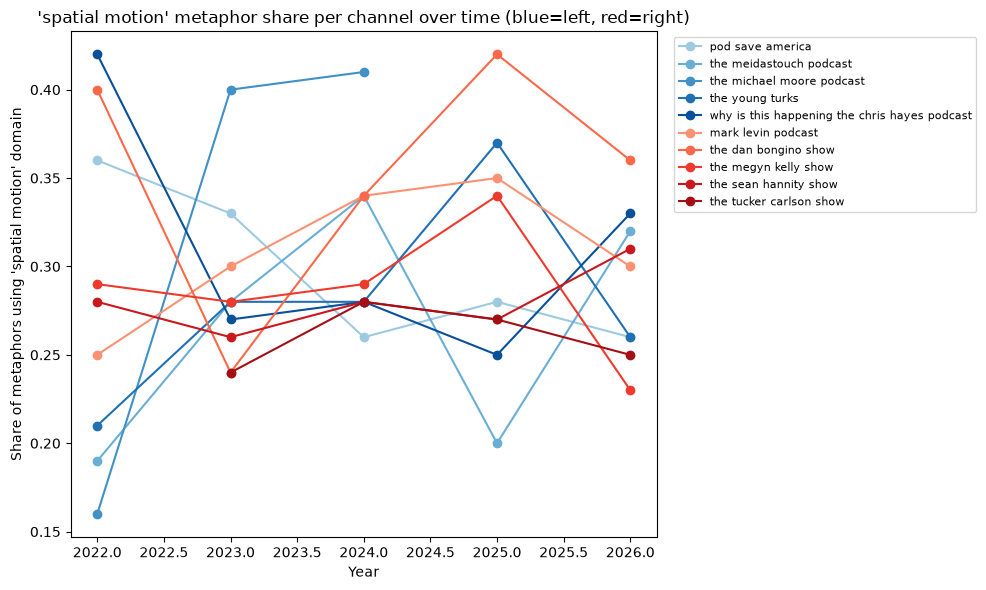

In [50]:
def plot_channel_schema_share_trend(df, schema='force'):
    grp = df.groupby(['doc_year','channel','polarity']).apply(
        lambda g: (g['source_image_schema_group']==schema).mean()
    ).reset_index(name='share')
    left_ch = sorted(grp[grp.polarity=='left']['channel'].unique())
    right_ch = sorted(grp[grp.polarity=='right']['channel'].unique())
    left_colors = sns.color_palette('Blues', n_colors=len(left_ch)+2)[2:]
    right_colors = sns.color_palette('Reds', n_colors=len(right_ch)+2)[2:]
    palette = dict(zip(left_ch, left_colors)) | dict(zip(right_ch, right_colors))
    fig, ax = plt.subplots(figsize=(10,6))
    for ch in channel_order:
        sub = grp[grp.channel==ch].sort_values('doc_year')
        ax.plot(sub['doc_year'], sub['share'], marker='o', label=ch, color=palette[ch])
    ax.set_xlabel('Year')
    ax.set_ylabel(f"Share of metaphors using '{schema}' domain")
    ax.set_title(f"'{schema}' metaphor share per channel over time (blue=left, red=right)")
    ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
    plt.tight_layout()
    return fig

fig12 = plot_channel_schema_share_trend(df, schema='spatial motion')

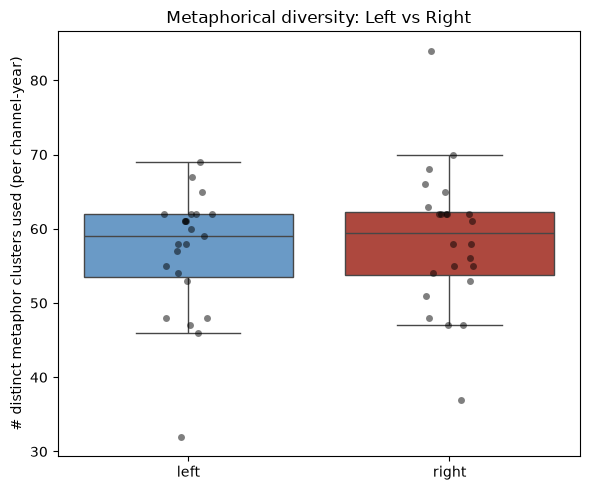

In [51]:
def plot_diversity_boxplot(df):
    div = df.groupby(['channel','doc_year','polarity'])['cluster'].nunique().reset_index(name='n_clusters')
    fig, ax = plt.subplots(figsize=(6,5))
    sns.boxplot(data=div, x='polarity', y='n_clusters', hue='polarity', order=['left','right'],
                palette={'left':'#5b9bd5','right':'#c0392b'}, ax=ax, showfliers=False, legend=False)
    sns.stripplot(data=div, x='polarity', y='n_clusters', order=['left','right'],
                  color='black', alpha=0.5, jitter=True, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('# distinct metaphor clusters used (per channel-year)')
    ax.set_title('Metaphorical diversity: Left vs Right')
    plt.tight_layout()
    return fig
fig = plot_diversity_boxplot(df)

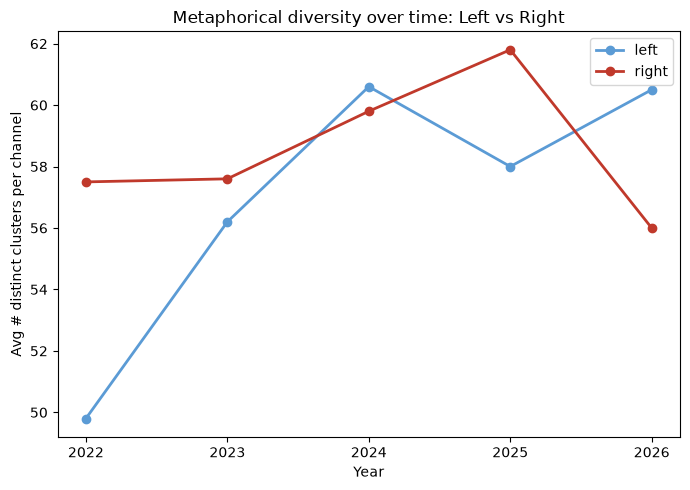

In [52]:
from matplotlib.ticker import MaxNLocator

def plot_polarity_diversity_trend(df, method='avg_per_channel'):
    if method == 'avg_per_channel':
        div = df.groupby(['channel','doc_year','polarity'])['cluster'].nunique().reset_index(name='n_clusters')
        trend = div.groupby(['doc_year','polarity'])['n_clusters'].mean().reset_index()
        ylabel = 'Avg # distinct clusters per channel'
    elif method == 'full_coverage_only':
        full_channels = df.groupby('channel')['doc_year'].nunique()
        full_channels = full_channels[full_channels == df['doc_year'].nunique()].index
        sub = df[df['channel'].isin(full_channels)]
        trend = sub.groupby(['doc_year','polarity'])['cluster'].nunique().reset_index(name='n_clusters')
        ylabel = f'# distinct clusters used (pooled, {len(full_channels)} full-coverage channels only)'
    else:
        raise ValueError("method must be 'avg_per_channel' or 'full_coverage_only'")

    fig, ax = plt.subplots(figsize=(7,5))
    for pol, color in [('left','#5b9bd5'), ('right','#c0392b')]:
        s = trend[trend.polarity==pol].sort_values('doc_year')
        ax.plot(s['doc_year'], s['n_clusters'], marker='o', label=pol, color=color, linewidth=2)
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.set_title('Metaphorical diversity over time: Left vs Right')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend()
    plt.tight_layout()
    return fig
fig = plot_polarity_diversity_trend(df)

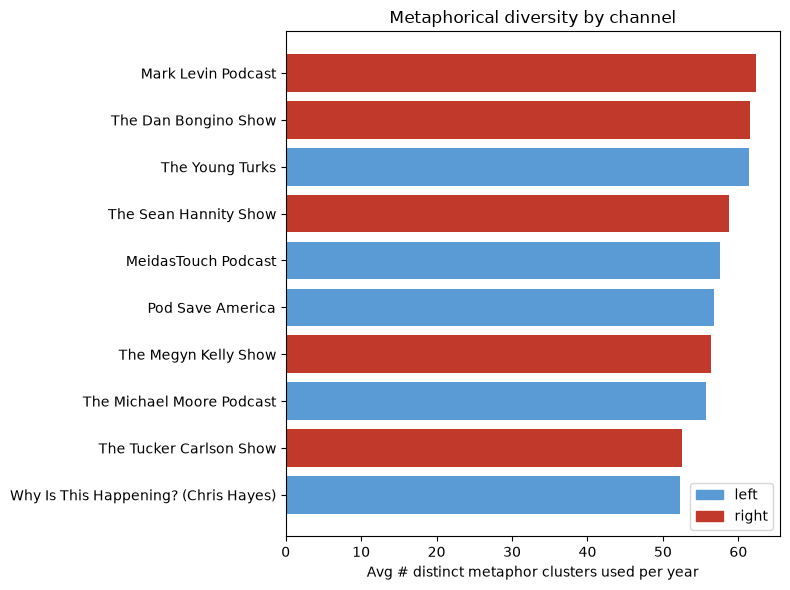

In [53]:
from matplotlib.patches import Patch

def plot_avg_diversity_by_channel(df):
    div = df.groupby(['channel_display','doc_year','polarity'])['cluster'].nunique().reset_index(name='n_clusters')
    avg = div.groupby(['channel_display','polarity'])['n_clusters'].mean().reset_index()
    avg = avg.sort_values('n_clusters')
    fig, ax = plt.subplots(figsize=(8,6))
    colors = ['#5b9bd5' if p=='left' else '#c0392b' for p in avg['polarity']]
    ax.barh(avg['channel_display'], avg['n_clusters'], color=colors)
    ax.set_xlabel('Avg # distinct metaphor clusters used per year')
    ax.set_title('Metaphorical diversity by channel')
    ax.legend(handles=[Patch(color='#5b9bd5', label='left'), Patch(color='#c0392b', label='right')])
    plt.tight_layout()
    return fig

fig = plot_avg_diversity_by_channel(df)